# Loss Function Experiments — Signed Error, MAE and MSE

This notebook experimentally investigates different ways of measuring regression error.

We compare:

1. Total Signed Error
2. Mean Absolute Error (MAE)
3. Mean Squared Error (MSE)

The experiments investigate:

- Error cancellation
- The effect of large residuals
- Sensitivity to outliers
- Why OLS produces a squared-error solution
- The difference between a regression objective and an evaluation metric

The experiments use synthetic data so that the underlying relationship is controlled and known.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

str(PROJECT_ROOT)

'/Users/shyamverma/ml_projects/slr_from_ols'

In [3]:
from src.linear_regression import SimpleLinearRegression
from src.metrics import mae, mse, rmse

In [5]:
# We have created a sample data
# And the relationship between y and x is y = 2 * x  + 1
x = np.array([1, 2, 3, 4, 5])

y_true = np.array([3, 5, 7, 9, 11])

In [6]:
# Creating two hypothetical models
y_pred_a = np.array([4, 4, 8, 8, 12])
y_pred_b = np.array([2, 6, 6, 12, 10])

In [7]:
residuals_a = y_true - y_pred_a
residuals_b = y_true - y_pred_b

print("Residuals A:", residuals_a)
print("Residuals B:", residuals_b)

Residuals A: [-1  1 -1  1 -1]
Residuals B: [ 1 -1  1 -3  1]


In [8]:
signed_error_a = np.sum(residuals_a)
signed_error_b = np.sum(residuals_b)

print("Model A signed error:", signed_error_a)
print("Model B signed error:", signed_error_b)

Model A signed error: -1
Model B signed error: -1


In [9]:
absolute_error_a = np.sum(np.abs(residuals_a))
absolute_error_b = np.sum(np.abs(residuals_b))

print("Model A absolute error:", absolute_error_a)
print("Model B absolute error:", absolute_error_b)

Model A absolute error: 5
Model B absolute error: 7


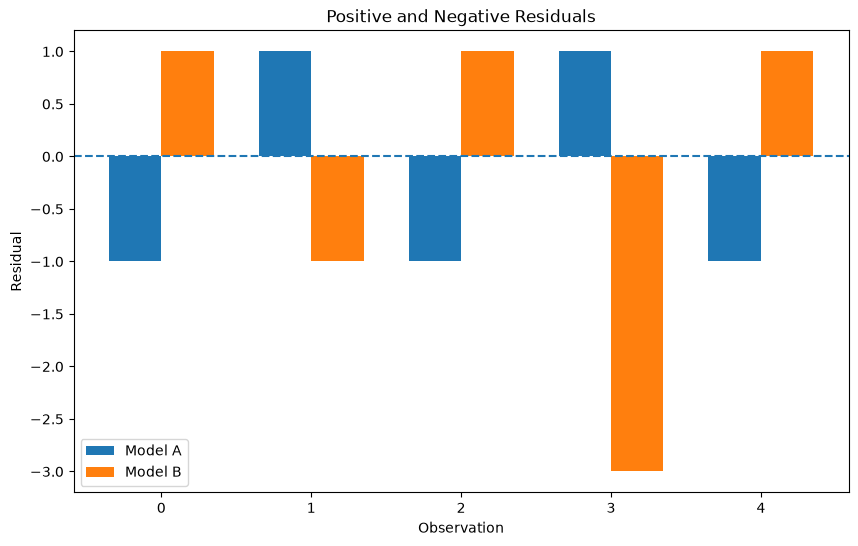

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

indices = np.arange(len(y_true))

width = 0.35

ax.bar(
    indices - width / 2,
    residuals_a,
    width,
    label="Model A"
)

ax.bar(
    indices + width / 2,
    residuals_b,
    width,
    label="Model B"
)

ax.axhline(
    y=0,
    linestyle="--"
)

ax.set_xlabel("Observation")
ax.set_ylabel("Residual")
ax.set_title("Positive and Negative Residuals")
ax.legend()

plt.show()

In [11]:
mae_a = mae(y_true, y_pred_a)
mae_b = mae(y_true, y_pred_b)

print("Model A MAE:", mae_a)
print("Model B MAE:", mae_b)

Model A MAE: 1.0
Model B MAE: 1.4


In [12]:
mse_a = mse(y_true, y_pred_a)
mse_b = mse(y_true, y_pred_b)

print("Model A MSE:", mse_a)
print("Model B MSE:", mse_b)

Model A MSE: 1.0
Model B MSE: 2.6


In [13]:
comparison = pd.DataFrame({
    "Model": ["A", "B"],
    "Signed Error": [signed_error_a, signed_error_b],
    "MAE": [mae_a, mae_b],
    "MSE": [mse_a, mse_b]
})

comparison

,Model,Signed Error,MAE,MSE
0,A,-1,1.0,1.0
1,B,-1,1.4,2.6


## Important Distinction

The fact that MAE and MSE can both be used to evaluate regression models does not mean that classical OLS uses MAE.

OLS is specifically defined by minimizing the sum of squared residuals:

SSE = Σ(yᵢ - ŷᵢ)²

MAE is a different objective and leads to a different optimization problem.

Therefore:

- MAE is a valid regression loss.
- MSE is a valid regression loss.
- Classical OLS minimizes squared error.

In [14]:
errors = np.array([1, 2, 3, 5, 10])

comparison = pd.DataFrame({
    "Error": errors,
    "Absolute Error": np.abs(errors),
    "Squared Error": errors ** 2
})

comparison

,Error,Absolute Error,Squared Error
0,1,1,1
1,2,2,4
2,3,3,9
3,5,5,25
4,10,10,100


In [15]:
errors = np.linspace(-10, 10, 400)

absolute_loss = np.abs(errors)
squared_loss = errors ** 2

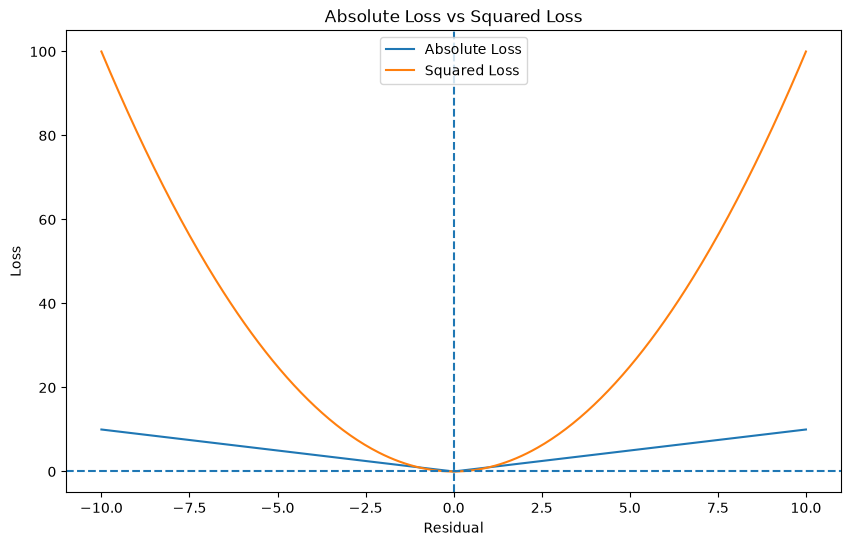

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    errors,
    absolute_loss,
    label="Absolute Loss"
)

plt.plot(
    errors,
    squared_loss,
    label="Squared Loss"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Loss")
plt.title("Absolute Loss vs Squared Loss")
plt.legend()

plt.show()

In [17]:
np.random.seed(42)

x = np.linspace(0, 10, 50)

noise = np.random.normal(
    loc=0,
    scale=1,
    size=len(x)
)

y = 3 * x + 5 + noise

In [19]:
model_clean = SimpleLinearRegression()

model_clean.fit(x, y)

In [20]:
print("Clean data slope:", model_clean.coef_)
print("Clean data intercept:", model_clean.intercept_)

Clean data slope: 2.942016600508177
Clean data intercept: 5.064443092202973


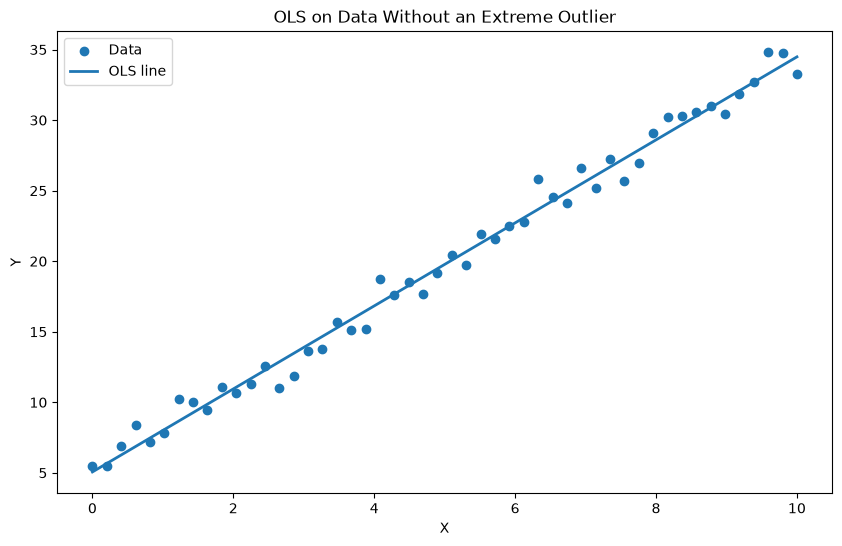

In [21]:
x_line = np.linspace(
    x.min(),
    x.max(),
    200
)

y_line = model_clean.predict(x_line)

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    label="Data"
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="OLS line"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("OLS on Data Without an Extreme Outlier")
plt.legend()

plt.show()

In [22]:
x_outlier = np.append(x, 10)
y_outlier = np.append(y, 60)

In [24]:
model_outlier = SimpleLinearRegression()

model_outlier.fit(x_outlier, y_outlier)

In [25]:
print("Without outlier:")
print("Slope:", model_clean.coef_)
print("Intercept:", model_clean.intercept_)

print("\nWith outlier:")
print("Slope:", model_outlier.coef_)
print("Intercept:", model_outlier.intercept_)

Without outlier:
Slope: 2.942016600508177
Intercept: 5.064443092202973

With outlier:
Slope: 3.214997856890939
Intercept: 4.173075724422528


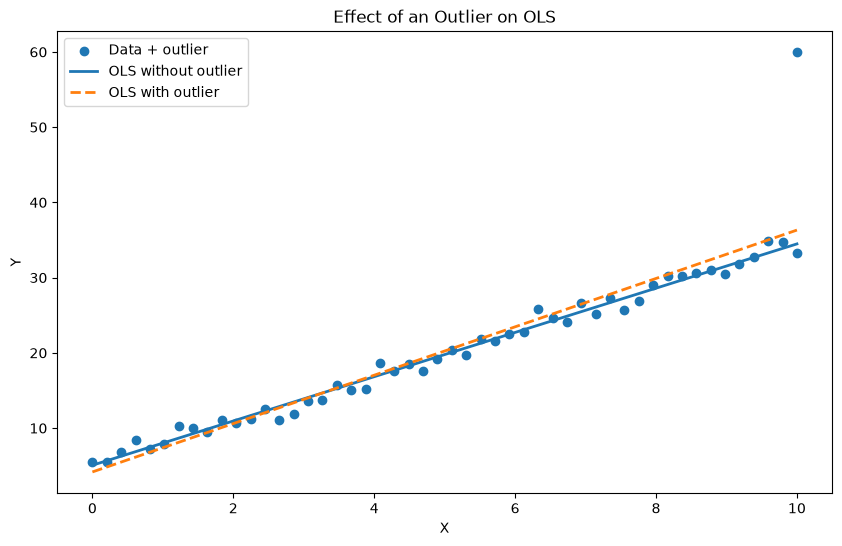

In [26]:
y_line_clean = model_clean.predict(x_line)
y_line_outlier = model_outlier.predict(x_line)

plt.figure(figsize=(10, 6))

plt.scatter(
    x_outlier,
    y_outlier,
    label="Data + outlier"
)

plt.plot(
    x_line,
    y_line_clean,
    linewidth=2,
    label="OLS without outlier"
)

plt.plot(
    x_line,
    y_line_outlier,
    linestyle="--",
    linewidth=2,
    label="OLS with outlier"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Effect of an Outlier on OLS")
plt.legend()

plt.show()

## Why Does the Outlier Affect OLS?

OLS minimizes:

SSE = Σeᵢ²

Therefore, a large residual receives a disproportionately large penalty.

For example:

e = 2  →  e² = 4

e = 10 →  e² = 100

An error five times larger produces a squared error twenty-five times larger.

Consequently, OLS can be highly sensitive to observations with unusually large residuals.

This sensitivity is a consequence of the squared-error objective rather than an implementation bug.

In [27]:
np.random.seed(42)

x = np.linspace(0, 10, 100)

noise_levels = [0.5, 2, 5]

In [28]:
results = []

for noise_level in noise_levels:

    noise = np.random.normal(
        0,
        noise_level,
        len(x)
    )

    y = 3 * x + 5 + noise

    model = SimpleLinearRegression()
    model.fit(x, y)

    results.append({
        "Noise SD": noise_level,
        "Slope": model.coef_,
        "Intercept": model.intercept_,
        "MSE": mse(y, model.predict(x)),
        "RMSE": rmse(y, model.predict(x))
    })

noise_results = pd.DataFrame(results)

noise_results

,Noise SD,Slope,Intercept,MSE,RMSE
0,0.5,3.006897,4.913594,0.203726,0.451360
1,2.0,3.004034,5.024439,3.601420,1.897741
2,5.0,2.834387,6.152549,28.864634,5.372582


## Experimental Conclusions

### Experiment 1 — Signed Error

Total signed error permits positive and negative residuals to cancel, making it unsuitable as a general regression objective.

### Experiment 2 — MAE

MAE removes cancellation and provides a linear penalty with respect to residual magnitude.

### Experiment 3 — MSE

MSE also removes cancellation while assigning disproportionately greater penalties to large residuals.

### Experiment 4 — Outliers

Because OLS minimizes squared residuals, extreme observations can substantially influence the fitted coefficients.

### Experiment 5 — Noise

Increasing noise increases prediction uncertainty and generally increases the achievable residual error, even when the underlying functional relationship remains unchanged.

Overall, the choice of loss function determines which types of prediction errors receive greater emphasis.